In [2]:
import joblib
joblib.parallel.DEFAULT_BACKEND = 'sequential'

In [3]:
import sys
import logging

import numpy as np
import hydra
from hydra.utils import instantiate
from omegaconf import DictConfig, OmegaConf
from mne_bids import BIDSPath
from pathlib import Path
from ieeg.calc.scaling import rescale
from bids.layout import BIDSLayout
from ieeg.navigate import trial_ieeg

# sys.path.insert(0, str(Path(__file__).resolve().parent))
# sys.path.insert('..')

from utils import snake2camel
from utils.config import normalize_cfg_items
from utils.preprocessing import (get_events, get_good_trials,
                                 preprocess_raw,
                                 preprocess_derivative_raw)
from utils.dataloaders import load_derivative_raw
from utils.phoneme import remap_phoneme_events
from utils.stats import get_significant_channels

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    stream=sys.stdout,
)
logger = logging.getLogger(__name__)


def calc_sig_channels(data, baseline, tw_interest=[-0.25, 0.25],
                      tw_baseline=[-0.5, 0]):
    logger.info('Calculating significant channels')
    sig_channels = get_significant_channels(data, baseline,
                                            tw_interest=tw_interest,
                                            tw_baseline=tw_baseline)
    logger.info(f'Found {len(sig_channels)} significant channels')
    # sig_channels = [str(int(ch)) for ch in sig_channels]
    return sig_channels


# @hydra.main(version_base=None, config_path="config",
#             config_name="extract_ieeg_epochs")
def main(cfg: DictConfig) -> None:
    missing_keys = OmegaConf.missing_keys(cfg)
    if missing_keys:
        raise RuntimeError(f'Missing configuration keys: {missing_keys}')

    logger.info(f'Running with configuration: {OmegaConf.to_yaml(cfg)}')

    cfg.bids_root = Path(cfg.bids_root).expanduser()

    bids_layout = BIDSLayout(root=cfg.bids_root,
                              derivatives=cfg.phoneme_level)

    # Full preprocessing: load -> outliers -> notch -> re-reference
    raw = preprocess_raw(bids_layout, cfg.patient, cfg.reference,
                         OmegaConf.to_container(cfg.load_kwargs))

    # Extract events aligned to stimulus and patient response onset
    stim_events, _ = get_events(raw, 'stimulus')
    resp_events, _ = get_events(raw, 'response')

    def get_tp_events(task_period):
        if task_period == 'stimulus':
            return stim_events
        elif task_period == 'response':
            return resp_events
        else:
            logger.error(f'Unknown task period: {task_period}')
            raise ValueError(f"Unknown task period: {task_period}")

    # Extract epochs for baseline period
    epochs_base = trial_ieeg(
        raw, event=stim_events, times=[-1, 0.5], preload=True,
    )

    # Extract general trial epochs for shared trial outlier removal
    # epochs_trial = trial_ieeg(
    #     raw, event=stim_events, times=[-1, 3], preload=True,
    # )
    epochs_trial = trial_ieeg(
        raw, event=resp_events, times=[-3, 3], preload=True,
    )

    # Bad trial removal using config parameters
    ts = cfg.trial_selection
    good_trials = get_good_trials(epochs_trial._data,
                                  threshold=ts.threshold,
                                  method=ts.method,
                                  chan_thresh=ts.chan_thresh)
    logger.info(f'Found {np.sum(good_trials)} good trials')

    # n_trials_total = len(epochs_base)

    # # Load task period and feature configs
    # task_periods = normalize_cfg_items(cfg.task_periods, 'cfg_task_periods')
    # features = normalize_cfg_items(cfg.features, 'cfg_features')

    # # Create output directory
    # epoch_dir = (f'epoch(phonemeLevel)({cfg.reference})' if cfg.phoneme_level
    #              else f'epoch({cfg.reference})')
    # outpath = BIDSPath(
    #     root=Path(bids_layout.root) / 'derivatives' / epoch_dir,
    #     subject=cfg.patient,
    #     task=cfg.task,
    #     datatype='epoch(raw)',
    #     check=False
    # )
    # outpath.mkdir(exist_ok=True)

    # epochs_base = epochs_base[good_trials]
    # epochs_base.save(
    #     outpath.copy().update(
    #         suffix="raw", extension=".fif",
    #         description="baseline", check=False
    #     ),
    #     overwrite=True
    # )

    # good_trials_feat = good_trials
    # nPhons = 1
    # if cfg.phoneme_level:
    #     logger.info('##### Phoneme-level mode: loading derivative raw #####')
    #     raw_phon = load_derivative_raw(
    #         bids_layout, cfg.patient, cfg.derivative_name,
    #         **OmegaConf.to_container(cfg.load_kwargs))
    #     raw_phon = preprocess_derivative_raw(raw_phon, raw, cfg.reference)

    #     phon_resp_events, _ = get_events(raw_phon, 'response')
    #     phon_epochs_count = trial_ieeg(
    #         raw_phon, event=phon_resp_events, times=[0, 0.1], preload=True)
    #     nPhons = len(phon_epochs_count) // n_trials_total
    #     logger.info(f'Phonemes per trial: {nPhons}')

    #     good_trials_feat = np.repeat(good_trials, nPhons)
    #     logger.info(f'Expanded good trials mask: {np.sum(good_trials)} trials '
    #                 f'-> {np.sum(good_trials_feat)} phoneme observations')

    #     raw = raw_phon
    #     stim_events, _ = get_events(raw, 'stimulus')
    #     resp_events, _ = get_events(raw, 'response')

    # for tp_cfg in task_periods:
    #     logger.info(f'##### Processing task period: {tp_cfg.name} #####')

    #     tp_events = get_tp_events(tp_cfg.align_to)

    #     epoch = trial_ieeg(
    #         raw, event=tp_events, times=tp_cfg.full_times, preload=True,
    #     )
    #     epoch = epoch[good_trials_feat]
    #     epoch.save(
    #         outpath.copy().update(
    #             datatype='epoch(raw)', suffix="raw", extension=".fif",
    #             description=tp_cfg.name, check=False
    #         ),
    #         overwrite=True
    #     )

    #     for feat_cfg in features:
    #         logger.info(f'--- Processing feature: {feat_cfg.name} ---')
    #         logger.info(f'Extracting {feat_cfg.name} features...')
    #         base_data = instantiate(feat_cfg.extractor,
    #                                 epochs=epochs_base.copy(),
    #                                 _convert_='all')
    #         logger.info('...extracted baseline features')

    #         feat_data = instantiate(feat_cfg.extractor, epochs=epoch.copy(),
    #                                 _convert_='all')
    #         logger.info('...extracted task features')

    #         logger.info(f'Cropping task data to {tp_cfg.feat_times[0]} to '
    #                     f'{tp_cfg.feat_times[1]} ms from {tp_cfg.name} anchor '
    #                     'onset')
    #         base_data = base_data.crop(tmin=-0.5, tmax=0)
    #         feat_data = feat_data.crop(tmin=tp_cfg.feat_times[0],
    #                                    tmax=tp_cfg.feat_times[1])

    #         if cfg.sig_channels:
    #             feat_data_sig = feat_data[::nPhons]
    #             sig_channels = calc_sig_channels(feat_data_sig, base_data,
    #                                              tw_interest=tp_cfg.sig_times)
    #             sig_channels_clean = [ch for ch in sig_channels if ch not in
    #                                   raw.info['bads']]
    #             logger.info(f'Found {len(sig_channels_clean)} significant '
    #                         'channels after removing bad channels')
    #             if len(sig_channels_clean) <= 0:
    #                 logger.warning('No significant channels found for '
    #                                f'{tp_cfg.name} {feat_cfg.name} data in '
    #                                f'{cfg.patient}. Skipping this feature.')
    #                 continue

    #         # Normalize by baseline
    #         logger.info(f'Normalizing {feat_cfg.name} features by baseline '
    #                     '(z-score)')
    #         feat_z = rescale(feat_data, base_data, mode='zscore', copy=True)
    #         logger.info(f'Normalizing {feat_cfg.name} features by baseline '
    #                     '(mean-subtraction)')
    #         feat_ms = rescale(feat_data, base_data, mode='mean', copy=True)

    #         if cfg.sig_channels:
    #             base_data.pick(sig_channels_clean)
    #             feat_data.pick(sig_channels_clean)
    #             feat_z.pick(sig_channels_clean)
    #             feat_ms.pick(sig_channels_clean)

    #         # Resample to lower frequency for output
    #         logger.info(f'Resampling {feat_cfg.name} to {feat_cfg.out_fs} Hz')
    #         base_data = base_data.resample(sfreq=feat_cfg.out_fs, n_jobs=-1)
    #         feat_z = feat_z.resample(sfreq=feat_cfg.out_fs, n_jobs=-1)
    #         feat_ms = feat_ms.resample(sfreq=feat_cfg.out_fs, n_jobs=-1)

    #         # Save band-specific epochs
    #         datatype = ('epoch(band)(power)(sig)' if cfg.sig_channels else
    #                     'epoch(band)(power)')
    #         outpath = outpath.update(
    #             datatype=datatype,
    #             suffix=snake2camel(feat_cfg.name),
    #             extension=".fif",
    #             check=False
    #         )
    #         outpath.mkdir(exist_ok=True)

    #         logger.info(f'Saving {tp_cfg.name} {feat_cfg.name} data to '
    #                     f'{outpath}...')
    #         base_data.save(outpath.copy().update(description="baseline"),
    #                        overwrite=True)
    #         feat_data.save(outpath.copy().update(description=tp_cfg.name),
    #                        overwrite=True)
    #         feat_z.save(outpath.copy().update(
    #                                     description=f"{tp_cfg.name}Zscore"),
    #                     overwrite=True)
    #         feat_ms.save(outpath.copy().update(
    #                                     description=f"{tp_cfg.name}MeanSub"),
    #                      overwrite=True)
            # logger.info('...saving successful')

2026-04-29 21:51:54 - INFO - Running with configuration: bids_root: ~/cworkspace/BIDS_1.0_Lexical_µECoG/BIDS
patient: S41
task: lexical
load_kwargs:
  preload: true
reference: CAR
sig_channels: true
trial_selection:
  method: 2
  threshold: 50
  chan_thresh: 0.8
task_periods:
- perception
- production
features:
- high_gamma
- spike_band
phoneme_level: false
derivative_name: phonemeLevel



Extracting EDF parameters from /hpc/home/zms14/cworkspace/BIDS_1.0_Lexical_µECoG/BIDS/sub-S41/ieeg/sub-S41_task-lexical_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /hpc/home/zms14/cworkspace/BIDS_1.0_Lexical_µECoG/BIDS/sub-S41/ieeg/sub-S41_task-lexical_events.tsv.
The event "response" refers to multiple event values.Creating hierarchical event names.
    Renaming event: response -> response/hazel
    Renaming event: response -> response/siren
    Renaming event: response -> response/vagul
    Renaming event: response -> response/minus
    Renaming event: response -> response/merit
    Renaming event: response -> response/lomic
    Renaming event: response -> response/bagel
    Renaming event: response -> response/minel
    Renaming event: response -> response/modem
    Renaming event: response -> response/fetal
    Renaming event: response -> response/nomel
    Renaming event: response -> response/rigid
    Renaming

[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  71 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 161 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done 256 out of 256 | elapsed:   11.9s finished


2026-04-29 21:52:45 - INFO - Setting re-reference scheme: CAR
Applying average reference.
Applying a custom ('ECoG',) reference.
2026-04-29 21:52:47 - INFO - Getting events from annotations with filter string: stimulus
Used Annotations descriptions: [np.str_('response/bacon'), np.str_('response/bagel'), np.str_('response/banel'), np.str_('response/basin'), np.str_('response/belet'), np.str_('response/beris'), np.str_('response/bonus'), np.str_('response/boreb'), np.str_('response/cazel'), np.str_('response/civil'), np.str_('response/comet'), np.str_('response/comic'), np.str_('response/davel'), np.str_('response/delin'), np.str_('response/denim'), np.str_('response/feral'), np.str_('response/fetal'), np.str_('response/folip'), np.str_('response/galef'), np.str_('response/gapel'), np.str_('response/halet'), np.str_('response/havel'), np.str_('response/haven'), np.str_('response/hazel'), np.str_('response/janep'), np.str_('response/jokeb'), np.str_('response/jural'), np.str_('response/ke

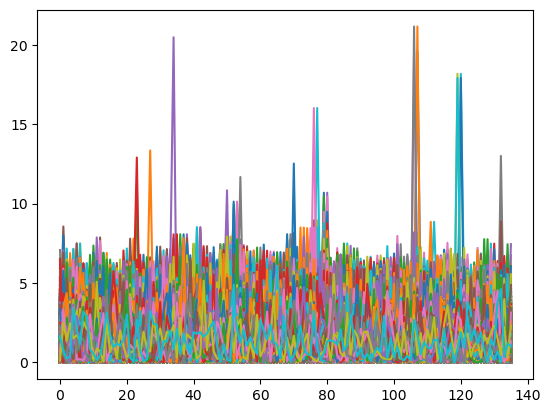

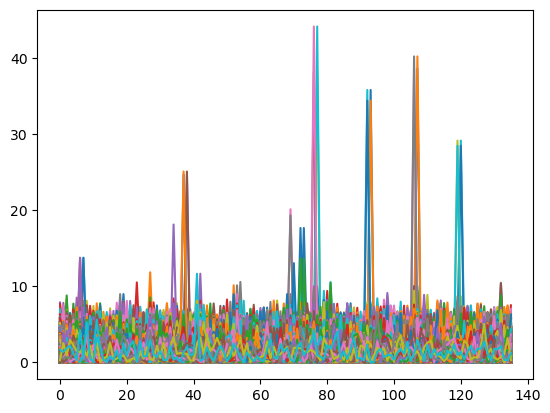

2026-04-29 21:55:59 - INFO - Found 134 good trials


In [4]:
# run main with hydra yaml config
cfg = OmegaConf.load('config/extract_ieeg_epochs.yaml')
main(cfg)